In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson

df = pd.read_csv(r"Book3.csv", dayfirst=True)
df.columns
variables = ['CPI', 'Sonia', 'Import_CVM', 'Export_cvm', 'GDP', 'wages']

############ SET WAGE VALUE FOR FEBRUARY ###### : 
df.iloc[-1,6] = 4
# CHANGECHANGECHANGECHANGECHANGECHANGECHANGE

df = df[["date_idx"] + variables].dropna()




df

,date_idx,CPI,Sonia,Import_CVM,Export_cvm,GDP,wages
50,200103.0,72.995,5.401686,42079,43944,71.4,6.1
51,200104.0,73.420,5.315916,41793,42801,71.2,6.2
52,200105.0,73.980,5.520267,41860,42266,71.3,5.1
53,200106.0,74.126,4.779619,43149,42783,71.6,5.5
54,200107.0,73.559,5.294264,41547,42032,71.6,5.2
...,...,...,...,...,...,...,...
345,202510.0,139.820,3.968170,82649,75350,102.3,4.8
346,202511.0,139.529,3.969250,81993,76256,102.5,4.6
347,202512.0,140.125,3.878871,80064,75600,102.6,4.2
348,202601.0,139.482,3.724990,79251,77692,102.6,3.9


### VAR(4) Model

We consider a VAR(p) model with the following vector:

$$
Y_t =
\begin{pmatrix}
\text{CPI,  } \
\text{GDP (Gross value added),  } \
\text{Export volumes,  } \
\text{SONIA rates,  }\
\text{Import volumes,  }\
\text{wages index,  }
\end{pmatrix}
$$

All variables are expressed in log-differences:

$$
Y_t = \log\left(\frac{X_t}{X_{t-1}}\right)
$$

The model is:

$$
Y_t = A_1 Y_{t-1} + A_2 Y_{t-2} + ....  + A_4 Y_{t-p} + \varepsilon_t
$$



In [2]:
# ── 2. ADF TEST (LEVELS) ──────────────────────────────────────────────────────
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="t-stat")
    stat = "✓ stationary" if result[1] < 0.05 else "✗ non-stationary"
    print(f"  {name:30s}: ADF={result[0]:7.3f}, p={result[1]:.3f}  {stat}")


print("\n=== ADF Tests (levels) ===")
for col in variables:
    adf_test(df[col], col)


=== ADF Tests (levels) ===
  CPI                           : ADF=  1.252, p=0.996  ✗ non-stationary
  Sonia                         : ADF= -1.940, p=0.314  ✗ non-stationary
  Import_CVM                    : ADF= -0.889, p=0.792  ✗ non-stationary
  Export_cvm                    : ADF= -1.044, p=0.737  ✗ non-stationary
  GDP                           : ADF= -1.018, p=0.747  ✗ non-stationary
  wages                         : ADF= -1.809, p=0.376  ✗ non-stationary


In [3]:
# ── 3. FIRST DIFFERENCE + ADF TEST ───────────────────────────────────────────

df_diff = pd.DataFrame(columns=variables)
non0_variables = ['CPI', 'Sonia', 'Import_CVM', 'Export_cvm', 'GDP', ]
df_diff[non0_variables] =np.log(df[non0_variables]).diff().dropna()
df_diff["wages"] = df["wages"].diff()

print("\n=== ADF Tests (first differences) ===")
for col in variables:
    adf_test(df_diff[col], col)
    


=== ADF Tests (first differences) ===
  CPI                           : ADF= -3.217, p=0.019  ✓ stationary
  Sonia                         : ADF=-10.902, p=0.000  ✓ stationary
  Import_CVM                    : ADF= -5.526, p=0.000  ✓ stationary
  Export_cvm                    : ADF= -4.609, p=0.000  ✓ stationary
  GDP                           : ADF= -6.128, p=0.000  ✓ stationary
  wages                         : ADF= -5.064, p=0.000  ✓ stationary


In [4]:
# ── 4. LAG ORDER SELECTION ────────────────────────────────────────────────────
model = VAR(df_diff)
lag_results = model.select_order(maxlags=4)
print("\n=== Lag Order Selection ===")
print(lag_results.summary())
optimal_lag = lag_results.aic
print(f"Optimal lag (AIC): {optimal_lag}")


=== Lag Order Selection ===
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -38.74      -38.66   1.504e-17      -38.71
1      -39.29     -38.77*   8.602e-18      -39.08
2      -39.60      -38.62   6.349e-18     -39.21*
3      -39.75      -38.33   5.450e-18      -39.18
4     -39.83*      -37.96  5.041e-18*      -39.08
-------------------------------------------------
Optimal lag (AIC): 4


c:\Users\hyper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [5]:
chosen_lag = 3

fitted = model.fit(chosen_lag)
print("\n=== VAR Model Summary ===")
print(fitted.summary())


=== VAR Model Summary ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Apr, 2026
Time:                     22:19:38
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -38.3189
Nobs:                     296.000    HQIC:                  -39.1712
Log likelihood:           3475.52    FPE:                5.51445e-18
AIC:                     -39.7402    Det(Omega_mle):     3.79655e-18
--------------------------------------------------------------------
Results for equation CPI
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.002266         0.000315            7.183           0.000
L1.CPI               -0.021843         0.059923           -0.365           0.715
L1.Sonia              0.003066     

February : all values defined 

March : (CPI) and SONIA 



In [6]:
rng = np.random.default_rng(seed=42)
i_c = 0 ###index of inflation
i_g = 4 ### index of GDP
h = 2
n_vars = 6
e = 1
N =10_000
Sigma_u = fitted.sigma_u
mar25_histo = df.iloc[-12][variables].values
apr25_histo = df.iloc[-11][variables].values
feb_histo = df.iloc[-1][variables]
mar_reconst = np.zeros((N,n_vars))
apr_reconst = np.zeros((N,n_vars))




##### MONTE CARLO LOOP : 
for s in range(N):
    # — February random choice : ————————————————————————————————————


    # # b — Forecast + bruit de mars depuis ce février ————————————
    point_mar   = fitted.forecast(df_diff.values[chosen_lag:],steps = 1)             # (1, n_vars)
    noise_mar   = rng.multivariate_normal(np.zeros(n_vars), Sigma_u)
    mar_draw    = point_mar[0] + noise_mar                    # (n_vars,)
    mar_reconst[s] = feb_histo * np.exp(mar_draw)
    mar_reconst[s][i_c] /= mar25_histo[i_c]
    mar_reconst[s][i_g] /= mar25_histo[i_g]
    
    # — Forecast + bruit d'avril depuis février ET mars ————————————
    history_mar = np.vstack([df_diff.values[chosen_lag:], mar_draw])
    point_apr   = fitted.forecast(history_mar, steps = 1)             # (1, n_vars)
    noise_apr   = rng.multivariate_normal(np.zeros(n_vars), Sigma_u)
    apr_draw    = point_apr[0] + noise_apr   # (n_vars,)
    apr_reconst[s] = mar_reconst[s] * np.exp(apr_draw)
    
    apr_reconst[s][i_c] /= apr25_histo[i_c]
    apr_reconst[s][i_g] /= apr25_histo[i_g]
    

reconst = np.stack([mar_reconst,apr_reconst])

reconst.shape


(2, 10000, 6)

In [12]:

# ── RECONSTRUCT df_recon WITH MC CONFIDENCE BANDS ────────────────────────────

confidence_levels = {
    "95": (2.5,  97.5),
    "90": (5.0,  95.0),
    "68": (16.0, 84.0),
}

# ── Historical part (levels, no uncertainty) ──────────────────────────────────
df_hist = df.iloc[1:].reset_index(drop=True).copy()  # align with df_diff
df_histt = pd.read_csv(r"Book3.csv", dayfirst=True)
df_histt["yoycpi"] = df_histt["CPI"]/df_histt["CPI"].diff(-12)-1
# ── Build forecast rows from MC simulations ───────────────────────────────────
# mc_results shape: (N_SIMULATIONS, h, n_vars)

forecast_rows = {}
for i, col in enumerate(df_diff.columns):
    col_sims = reconst[:, :, i].T  # shape (N_SIMULATIONS, h)

    forecast_rows[col]             = np.mean(col_sims, axis=0)   # (h,)
    for label, (lo, hi) in confidence_levels.items():
        forecast_rows[f"{col}_min_{label}"] = np.percentile(col_sims, lo,  axis=0)
        forecast_rows[f"{col}_max_{label}"] = np.percentile(col_sims, hi,  axis=0)

df_forecast_bands = pd.DataFrame(forecast_rows)  # shape (h, n_cols)

df_forecast_bands

,CPI,CPI_min_95,CPI_max_95,CPI_min_90,CPI_max_90,CPI_min_68,CPI_max_68,Sonia,Sonia_min_95,Sonia_max_95,...,GDP_max_90,GDP_min_68,GDP_max_68,wages,wages_min_95,wages_max_95,wages_min_90,wages_max_90,wages_min_68,wages_max_68
0,1.027655,1.019953,1.035521,1.021272,1.034124,1.023798,1.031574,3.869638,2.911180,5.077389,...,1.036696,0.997935,1.026623,5.860744,2.157526,12.985796,2.474678,11.279806,3.338022,8.330082
1,0.007455,0.007375,0.007536,0.007387,0.007522,0.007414,0.007495,3.811289,2.344387,5.916733,...,0.010284,0.009654,0.010120,9.034898,1.306987,32.232101,1.659276,24.758689,2.862018,14.564549


In [13]:
df_histt = pd.read_csv(r"Book3.csv", dayfirst=True)
df_histt["yoycpi"] = df_histt["CPI"]/df_histt["CPI"].diff(12)-1
df_histt

,Date,CPI,Sonia,Import_CVM,Export_cvm,GDP,wages,date_idx,yoycpi
0,Jan-97,69.231,5.900455,30089,36016,61.6,NaN,NaN,NaN
1,Feb-97,69.399,5.985000,29909,35279,61.9,NaN,NaN,NaN
2,Mar-97,69.549,5.965068,30864,34438,61.8,NaN,NaN,NaN
3,Apr-97,69.805,5.961832,31679,36607,62.6,NaN,NaN,NaN
4,May-97,70.021,6.215380,31202,35468,62.1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
345,Oct-25,139.820,3.968170,82649,75350,102.3,4.8,202510.0,28.098855
346,Nov-25,139.529,3.969250,81993,76256,102.5,4.6,202511.0,30.790613
347,Dec-25,140.125,3.878871,80064,75600,102.6,4.2,202512.0,29.641811
348,Jan-26,139.482,3.724990,79251,77692,102.6,3.9,202601.0,33.195146


In [9]:
h=2
# — Pad historical rows with NaN for the band columns ————————————————
band_cols = [c for c in df_forecast_bands.columns if c not in df_diff.columns]

for col in band_cols:
    df_hist[col] = np.nan    # no uncertainty on observed data

# For the original columns in history, min/max == the observed value itself
for col in df_diff.columns:
    for label in confidence_levels:
        df_hist[f"{col}_min_{label}"] = df_hist[col]
        df_hist[f"{col}_max_{label}"] = df_hist[col]

# — Stack history + forecast ————————————————————————————————————————
df_recon = pd.concat(
    [df_hist, df_forecast_bands],
    ignore_index=True
)

# — Flag which rows are forecasted ——————————————————————————————————
df_recon["is_forecast"] = False
df_recon.loc[len(df_hist):, "is_forecast"] = True

for i in range(len(df_diff), len(df_diff)+h):
    df_recon.loc[df_recon.index[i], "date_idx"] = df_recon.loc[df_recon.index[i-1], "date_idx"] + 1

df_recon["date_idx"] = df_recon.date_idx.apply(lambda x: round(x)*100 + 1)
df_recon["date_idx"] = pd.to_datetime(df_recon.date_idx, format="%Y%m%d")
df_recon

,date_idx,CPI,Sonia,Import_CVM,Export_cvm,GDP,wages,CPI_min_95,CPI_max_95,CPI_min_90,...,GDP_max_90,GDP_min_68,GDP_max_68,wages_min_95,wages_max_95,wages_min_90,wages_max_90,wages_min_68,wages_max_68,is_forecast
0,2001-04-01,73.420000,5.315916,41793.000000,42801.000000,71.200000,6.200000,73.420000,73.420000,73.420000,...,71.200000,71.200000,71.200000,6.200000,6.200000,6.200000,6.200000,6.200000,6.200000,False
1,2001-05-01,73.980000,5.520267,41860.000000,42266.000000,71.300000,5.100000,73.980000,73.980000,73.980000,...,71.300000,71.300000,71.300000,5.100000,5.100000,5.100000,5.100000,5.100000,5.100000,False
2,2001-06-01,74.126000,4.779619,43149.000000,42783.000000,71.600000,5.500000,74.126000,74.126000,74.126000,...,71.600000,71.600000,71.600000,5.500000,5.500000,5.500000,5.500000,5.500000,5.500000,False
3,2001-07-01,73.559000,5.294264,41547.000000,42032.000000,71.600000,5.200000,73.559000,73.559000,73.559000,...,71.600000,71.600000,71.600000,5.200000,5.200000,5.200000,5.200000,5.200000,5.200000,False
4,2001-08-01,73.852000,4.804627,42571.000000,41490.000000,71.700000,5.300000,73.852000,73.852000,73.852000,...,71.700000,71.700000,71.700000,5.300000,5.300000,5.300000,5.300000,5.300000,5.300000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,2025-12-01,140.125000,3.878871,80064.000000,75600.000000,102.600000,4.200000,140.125000,140.125000,140.125000,...,102.600000,102.600000,102.600000,4.200000,4.200000,4.200000,4.200000,4.200000,4.200000,False
297,2026-01-01,139.482000,3.724990,79251.000000,77692.000000,102.600000,3.900000,139.482000,139.482000,139.482000,...,102.600000,102.600000,102.600000,3.900000,3.900000,3.900000,3.900000,3.900000,3.900000,False
298,2026-02-01,140.066000,3.727350,81435.000000,76538.000000,103.000000,4.000000,140.066000,140.066000,140.066000,...,103.000000,103.000000,103.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,False
299,2026-03-01,1.027655,3.869638,82519.259885,77265.839655,1.012293,5.860744,1.019953,1.035521,1.021272,...,1.036696,0.997935,1.026623,2.157526,12.985796,2.474678,11.279806,3.338022,8.330082,True


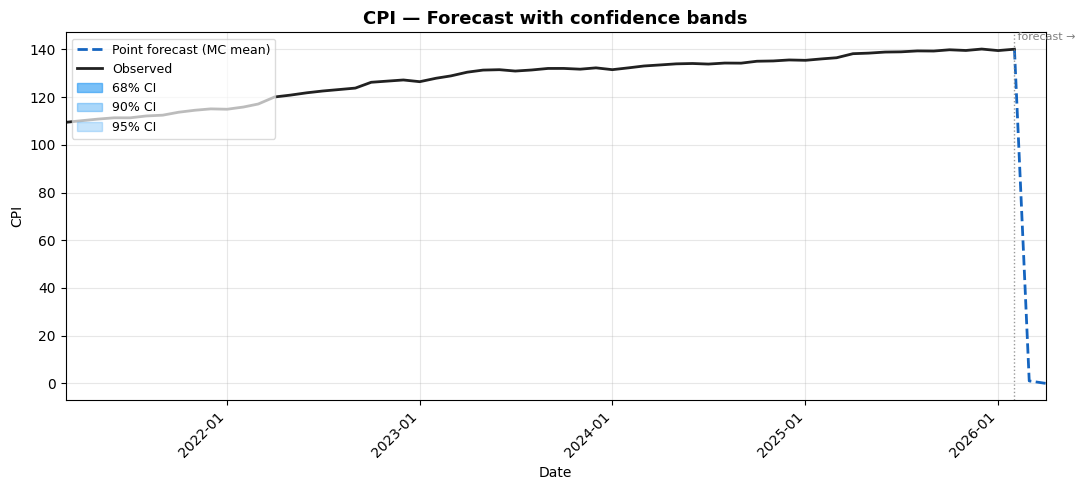

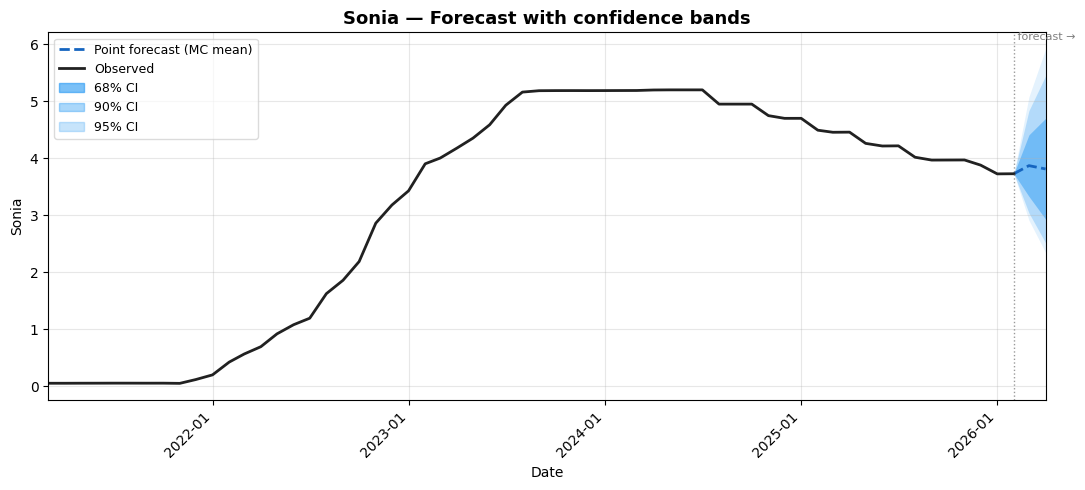

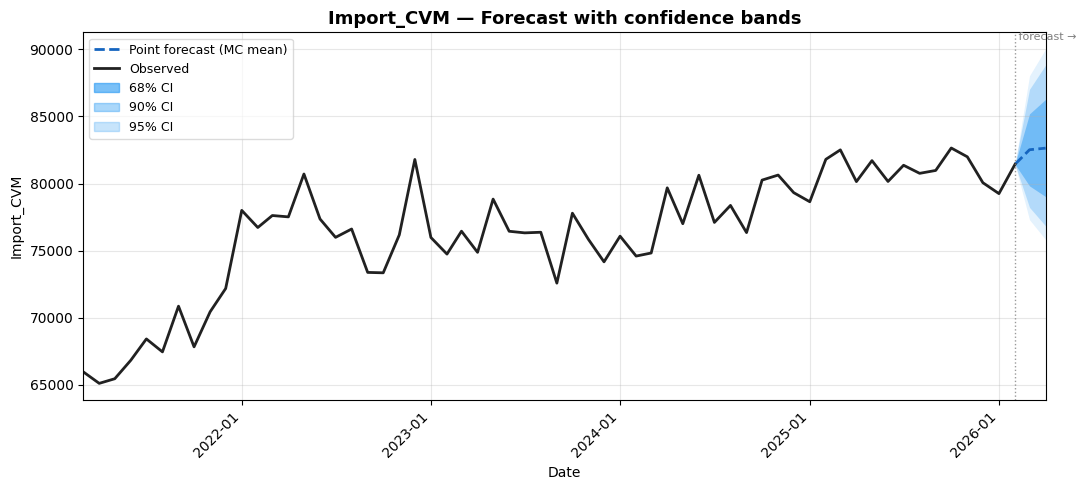

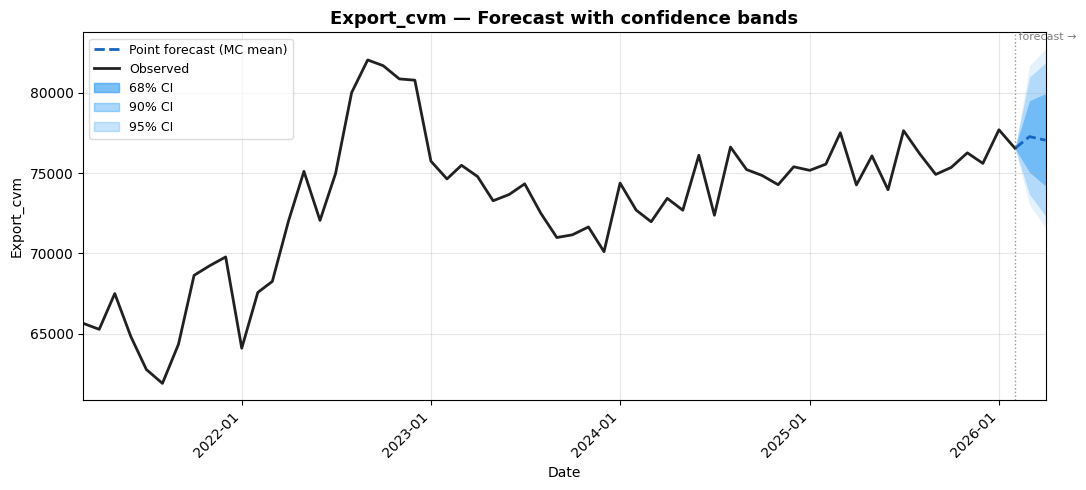

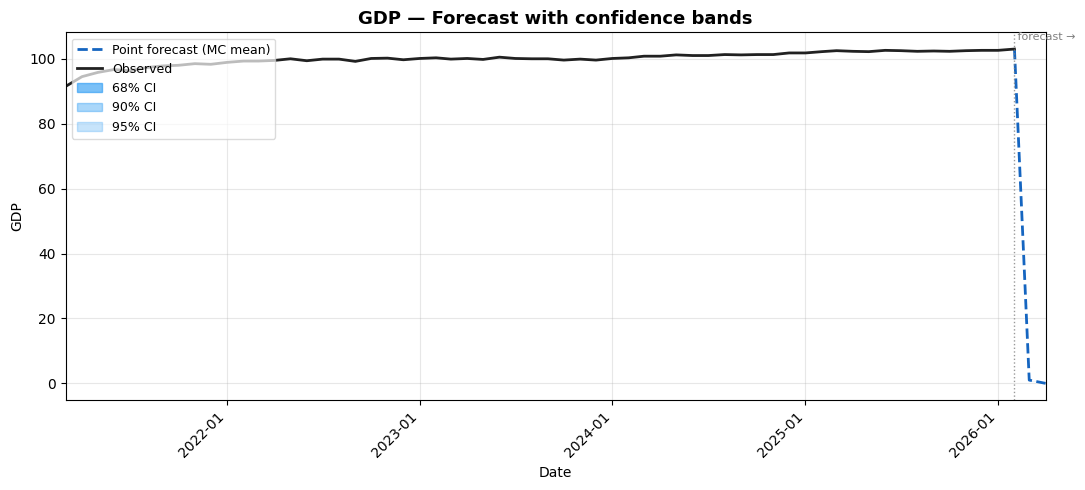

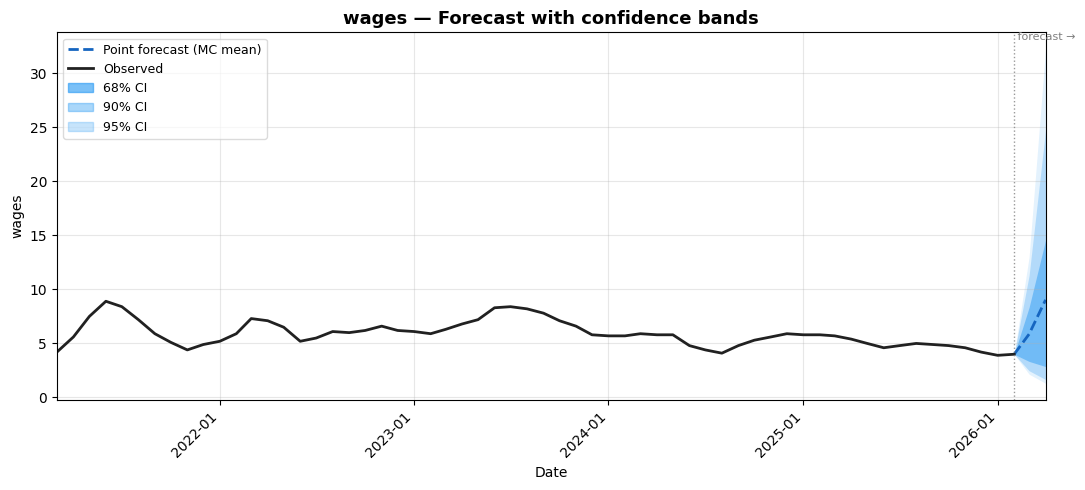

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_forecast_cone(df_recon, col, confidence_levels, n_hist=30):
    """
    Plot historical values + forecast cone with confidence bands for one variable.
    
    Parameters
    ----------
    df_recon          : full reconstructed DataFrame
    col               : variable name to plot (e.g. "GDP")
    confidence_levels : dict {"95": (2.5, 97.5), ...}
    n_hist            : number of historical points to show before the forecast
    """

    df_hist_plot = df_recon[~df_recon["is_forecast"]].tail(n_hist)
    df_fore_plot = df_recon[df_recon["is_forecast"]]

    # Last historical point — used to connect history to forecast smoothly
    last_hist = df_recon[~df_recon["is_forecast"]].iloc[[-1]]

    fig, ax = plt.subplots(figsize=(11, 5))

    # ── Color palette per confidence level ────────────────────────────────────
    band_styles = {
        "68": dict(color="#2196F3", alpha=0.45, label="68% CI"),
        "90": dict(color="#2196F3", alpha=0.25, label="90% CI"),
        "95": dict(color="#2196F3", alpha=0.12, label="95% CI"),
    }

    for label in ["95", "90", "68"]:
        style = band_styles[label]

        stitched = pd.concat([last_hist, df_fore_plot])
        x_band = stitched["date_idx"].values          # ← .values pour sortir du pandas index

        y_lo = np.concatenate([
            last_hist[col].values,
            df_fore_plot[f"{col}_min_{label}"].values
        ])
        y_hi = np.concatenate([
            last_hist[col].values,
            df_fore_plot[f"{col}_max_{label}"].values
        ])

        ax.fill_between(x_band, y_lo, y_hi,
                        color=style["color"], alpha=style["alpha"], linewidth=0)

    # ── Point forecast ────────────────────────────────────────────────────────────
    x_fore = pd.concat([last_hist, df_fore_plot])["date_idx"].values   # ← .values
    y_fore = np.concatenate([last_hist[col].values, df_fore_plot[col].values])

    ax.plot(x_fore, y_fore, color="#1565C0", linewidth=2,
            linestyle="--", label="Point forecast (MC mean)")

    # ── Historical line ───────────────────────────────────────────────────────
    ax.plot(df_hist_plot["date_idx"], df_hist_plot[col],
            color="#212121", linewidth=2, label="Observed")

    # ── Vertical separator history / forecast ─────────────────────────────────
    sep = last_hist["date_idx"].values[0]
    ax.axvline(sep, color="grey", linewidth=1, linestyle=":", alpha=0.8)
    ax.text(sep, ax.get_ylim()[1],
            " forecast →", fontsize=8, color="grey", va="top")

    # ── Legend ────────────────────────────────────────────────────────────────
    band_patches = [
        mpatches.Patch(color="#2196F3", alpha=0.60, label="68% CI"),
        mpatches.Patch(color="#2196F3", alpha=0.38, label="90% CI"),
        mpatches.Patch(color="#2196F3", alpha=0.25, label="95% CI"),
    ]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + band_patches,
              loc="upper left", fontsize=9, framealpha=0.7)

    # ── X axis formatting ─────────────────────────────────────────────────────
    # Tighten x limits to exactly the visible window (history + forecast)
    x_min = df_hist_plot["date_idx"].iloc[0]
    x_max = df_fore_plot["date_idx"].iloc[-1]
    ax.set_xlim(x_min, x_max)

    fig.autofmt_xdate(rotation=45)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%Y-%m"))

    ax.set_title(f"{col} — Forecast with confidence bands", fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


# ── Ensure date_idx is datetime before plotting ───────────────────────────────
df_recon["date_idx"] = pd.to_datetime(df_recon["date_idx"])

# ── Plot all variables ────────────────────────────────────────────────────────
for col in variables:
    plot_forecast_cone(df_recon, col, confidence_levels, n_hist=60)